# **Customer Churn Prediction Using Machine Learning at Eurotel**

This is a python notebook constructed by the **[Centre for Financial Leadership and Digital Transformation](https://www.vlerick.com/en/for-companies/research-for-your-company/centre-for-financial-leadership-and-digital-transformation/)** at **Vlerick Business School**. This notebok is the first notebook of the Eurotel case, focusing on Customer Churn Prediction using Machine Learning. *For specific questions or troubleshooting during your self-paced session please message the following email addresses*:

*   carlerik.heyvaert@vlerick.com
*   angel.oganesian@vlerick.com

## Main Resources
### Python

<img src="https://www.dropbox.com/scl/fi/tjturc2paqiuhlkt39jpt/whypython.png?rlkey=co4doeovh9d58jh4d7ts4674p&raw=1" width="80%" style="float:center">

### Jupyter Notebooks & Google Colab

<img src="https://www.dropbox.com/scl/fi/8iye8hqs4afsk9q4oe0ru/juptyterlab-colab-logos.png?rlkey=01e80tqwopdfqr22cfdie2x2z&raw=1" width="80%" style="float:center">

For this course we use Google Colab. It is a hosted Jupyter Notebook service that requires no setup to use and provides free access to computing resources, including GPUs and TPUs. Colab is especially well suited to machine learning, data science, and education purposes

### CRISP-DM
<center>
<img src="https://www.dropbox.com/scl/fi/vrdehconzfgjspdgqnls3/crisp-dm.png?rlkey=fx8hanrsv2ojskusax1clxanb&raw=1" width="45%" style="float:center">

### Workflow
<center>
<img src="https://www.dropbox.com/scl/fi/hy5ss7j6tuzpjdbgcq15z/workflow_packages_churn_clv.png?rlkey=7ojb6e3zlt08fn4f7uoz3uq90&raw=1" width="90%" style="float:center">

## Business Understanding

**What**:
- *Eurotel* is a high-growth telecommunications firm that is trying to compete in the <u>highly competitive</u> Telecom market. <br>
- **Customer churn** is the percentage of customers who leave the company in an average month.
- The company wants to build a model to predict whether a customer will churn.

**Why**:
- The cost of retaining an existing customer is far less than acquiring a new one.
- Churn shortens customer lifetimes, and CLV is the monetary measure of those lifetimes.
- Churn rate will therefore influence firms' profitability
- Helps to develop strategies on how to retain customers and how to win back defecting clients.

**How**:
- Each data point is labeled as either 0 (no churn) or 1 (churn).
- We train multiple machine learning models to predict the probability of churn for each customer.
- We use a threshold of 0.5: If the probability is greater than 0.5, the customer is classified as 1 (churn).

<img  align="center" src="https://www.dropbox.com/scl/fi/utka0j9ejglxvuockhu4w/ChurnIcon.jpg?rlkey=v88nswz5868l7fap6vx0zdzli&raw=1" height=50% width=50%/>




### Import the packages

In [ ]:
import numpy as np
import pandas as pd

import copy
import missingno as msno
import warnings
import os

# visualization packages
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.express as ply
import plotly.graph_objs as go
from matplotlib.colors import LinearSegmentedColormap
from pandas.api.types import is_numeric_dtype

# machine learning packages
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, \
  accuracy_score, f1_score, recall_score, precision_score, average_precision_score,\
  precision_recall_curve, roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import plot_tree, export_text, DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.utils import resample
import xgboost as xgb
from xgboost import plot_importance


from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')


### Reading in the Eurotel data

The variables utilized in this case are explained in the case document throughout Exhibit 1 and Exhibit 2. You can find this document on Canvas as "Customer Churn Prediction Using Machine Learning - Eurotel (A)".

In [ ]:
%%capture

# download data from google drive to colab
!wget https://drive.google.com/uc?id=1lIRZiMjeE8Taaks6kRZ-F3_AVDaQ5N7I -O Eurotel_churn_data_cleaned.csv

In [ ]:
df_eurotel = pd.read_csv("Eurotel_churn_data_cleaned.csv").set_index("customerID") # we set the index as customerID
pd.set_option('display.max_columns', None)
df_eurotel

,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn,Young,RevenuePerUser,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalRevenue
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,
0002-ORFBO,0,1,1,9,1,0,1,0,1,1,0,1,0,0,73.5,0,0,1,0,0,1,0,0,0,0,1,661.5
0003-MKNFE,0,0,0,9,1,0,0,0,0,0,1,0,0,0,71.2,1,0,1,0,1,0,0,0,0,0,1,640.8
0004-TLHLJ,0,0,0,4,1,0,0,1,0,0,0,1,1,0,58.5,1,1,0,0,1,0,0,0,0,1,0,234.0
0011-IGKFF,1,0,0,13,1,0,1,1,0,1,1,1,1,0,82.0,1,1,0,0,1,0,0,0,0,1,0,1066.0
0013-EXCHZ,1,0,0,3,1,0,0,0,1,1,0,1,1,0,68.0,0,1,0,0,1,0,0,0,0,0,1,204.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987-LUTYD,0,0,0,13,1,1,0,0,1,0,0,0,0,0,66.7,0,0,1,0,0,1,0,0,0,0,1,867.1
9992-RRAMN,0,1,0,22,1,0,0,0,0,0,1,1,1,0,68.0,1,1,0,0,1,0,0,0,0,1,0,1496.0
9992-UJOEL,0,0,0,2,1,0,1,0,0,0,0,1,0,0,60.5,1,0,1,0,1,0,0,0,0,0,1,121.0


## Data Cleaning and Exploration

To ease interpretation, we replace InternetService_No with InternetService.

In [ ]:
df_eurotel['InternetService_No'] = df_eurotel['InternetService_No'].replace({0: 1, 1: 0})
churn = df_eurotel.rename(columns= {"InternetService_No": "InternetService"})
churn.head(5)

,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn,Young,RevenuePerUser,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalRevenue
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,
0002-ORFBO,0,1,1,9,1,0,1,0,1,1,0,1,0,0,73.5,0,0,1,1,0,1,0,0,0,0,1,661.5
0003-MKNFE,0,0,0,9,1,0,0,0,0,0,1,0,0,0,71.2,1,0,1,1,1,0,0,0,0,0,1,640.8
0004-TLHLJ,0,0,0,4,1,0,0,1,0,0,0,1,1,0,58.5,1,1,0,1,1,0,0,0,0,1,0,234.0
0011-IGKFF,1,0,0,13,1,0,1,1,0,1,1,1,1,0,82.0,1,1,0,1,1,0,0,0,0,1,0,1066.0
0013-EXCHZ,1,0,0,3,1,0,0,0,1,1,0,1,1,0,68.0,0,1,0,1,1,0,0,0,0,0,1,204.0


### A first peek at the Eurotel data

Provide code that gives insights into the dataframe provided. For instance, you could explore methods that explore the shape, an overview of the variables and counts for the amount of Churn and No Churn customers.

In [ ]:
#Code for the shape of the dataset (number of rows, number of columns)
print(churn.shape)

(7041, 27)


In [ ]:
#Code for printing an overview of the data types
churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7041 entries, 0002-ORFBO to 9995-HOTOH
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7041 non-null   int64  
 1   Partner                                  7041 non-null   int64  
 2   Dependents                               7041 non-null   int64  
 3   Tenure                                   7041 non-null   int64  
 4   PhoneService                             7041 non-null   int64  
 5   OnlineSecurity                           7041 non-null   int64  
 6   OnlineBackup                             7041 non-null   int64  
 7   DeviceProtection                         7041 non-null   int64  
 8   TechSupport                              7041 non-null   int64  
 9   StreamingTV                              7041 non-null   int64  
 10  StreamingMovies                       

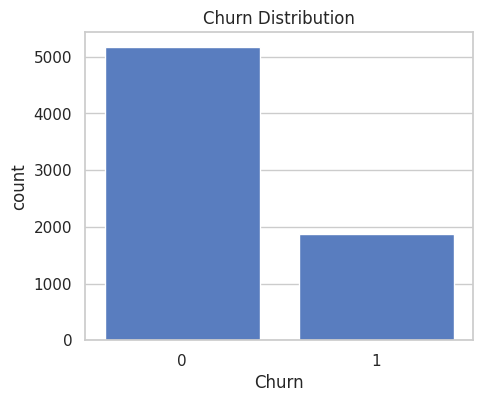

In [ ]:
#Code that prints the amount of customers that churn or not
churn["Churn"].value_counts()

# Set style
sns.set(style="whitegrid", palette="muted", color_codes=True)

# ==========================
# Churn distribution
# ==========================
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=churn)
plt.title("Churn Distribution")
plt.show()

Most of our clients are (luckily) not churning, but this also means that we have an imbalanced dataset.

#### Density Plots

They visualize how numeric features differ between churners and non-churners

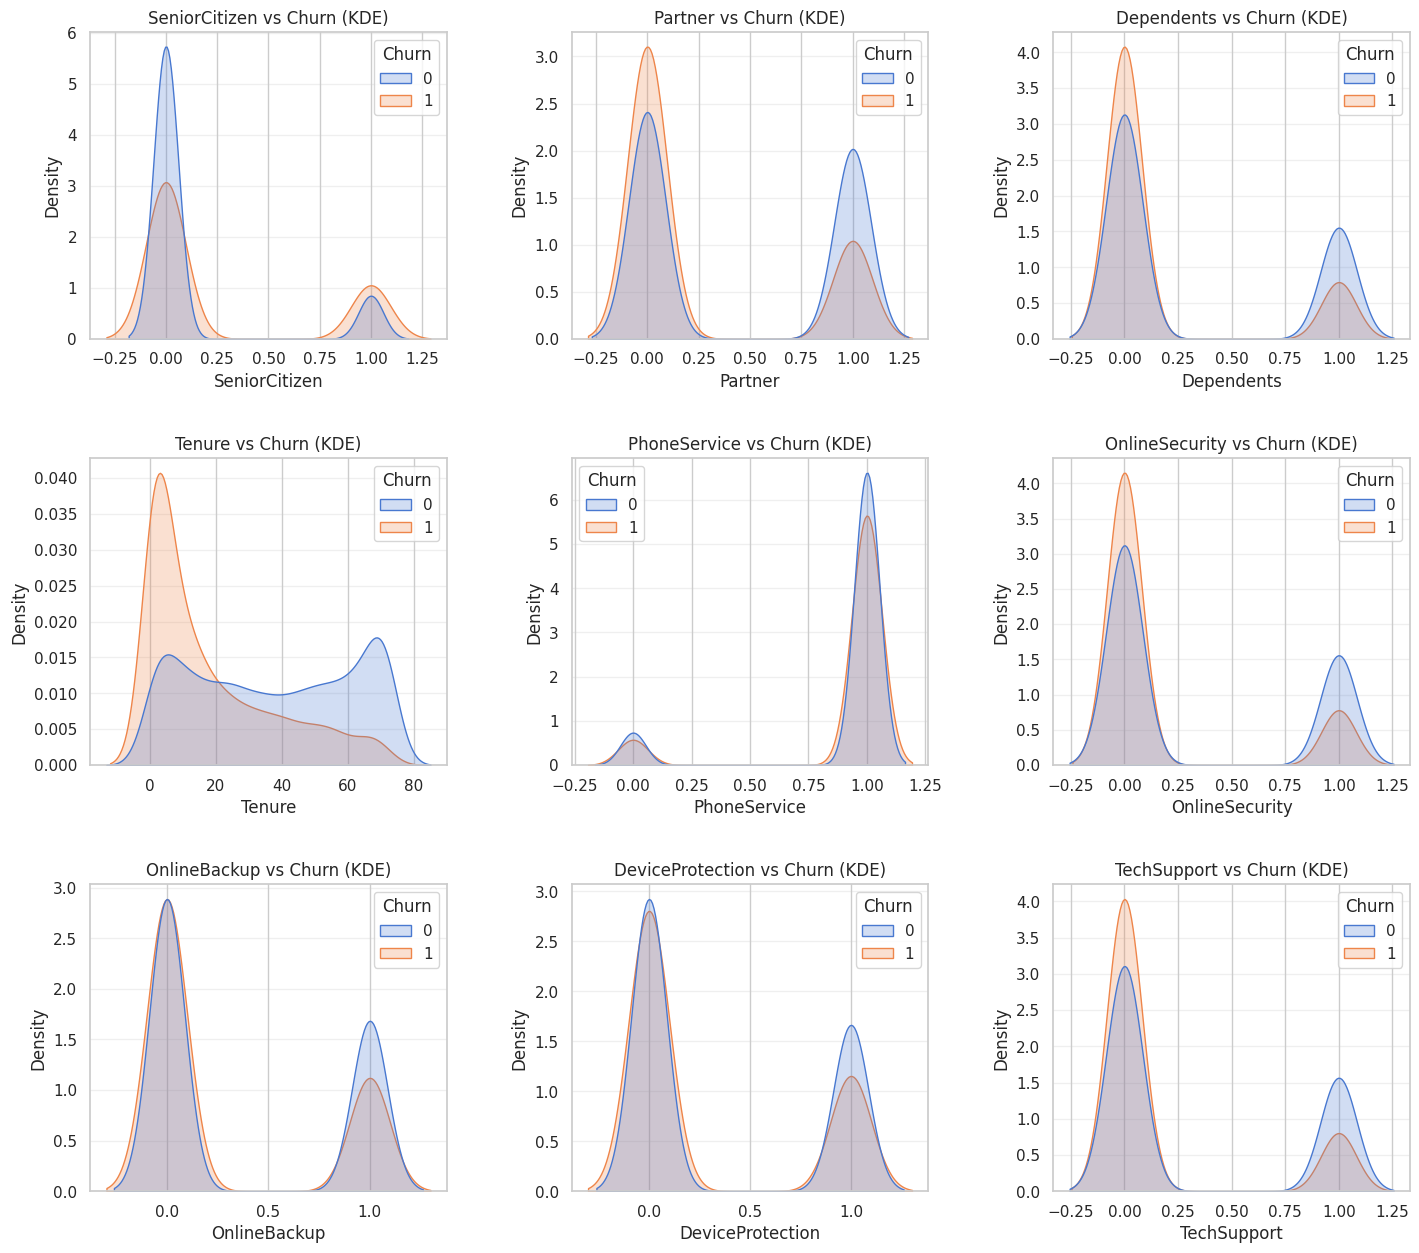

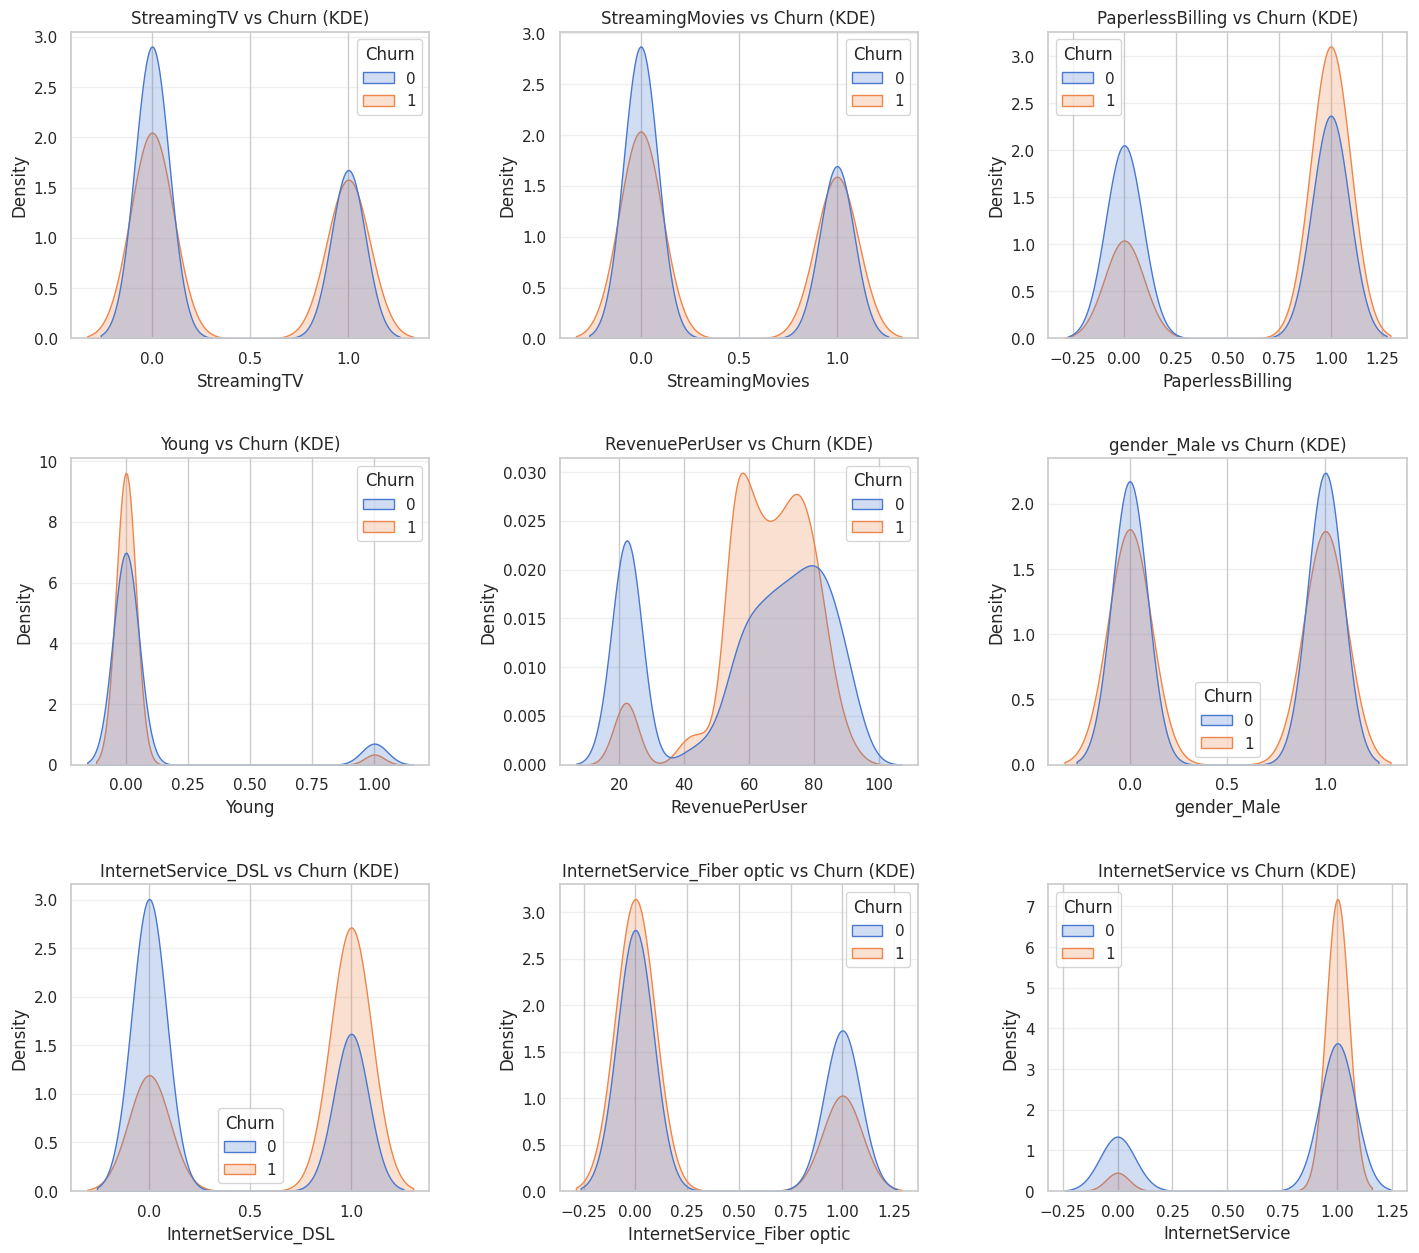

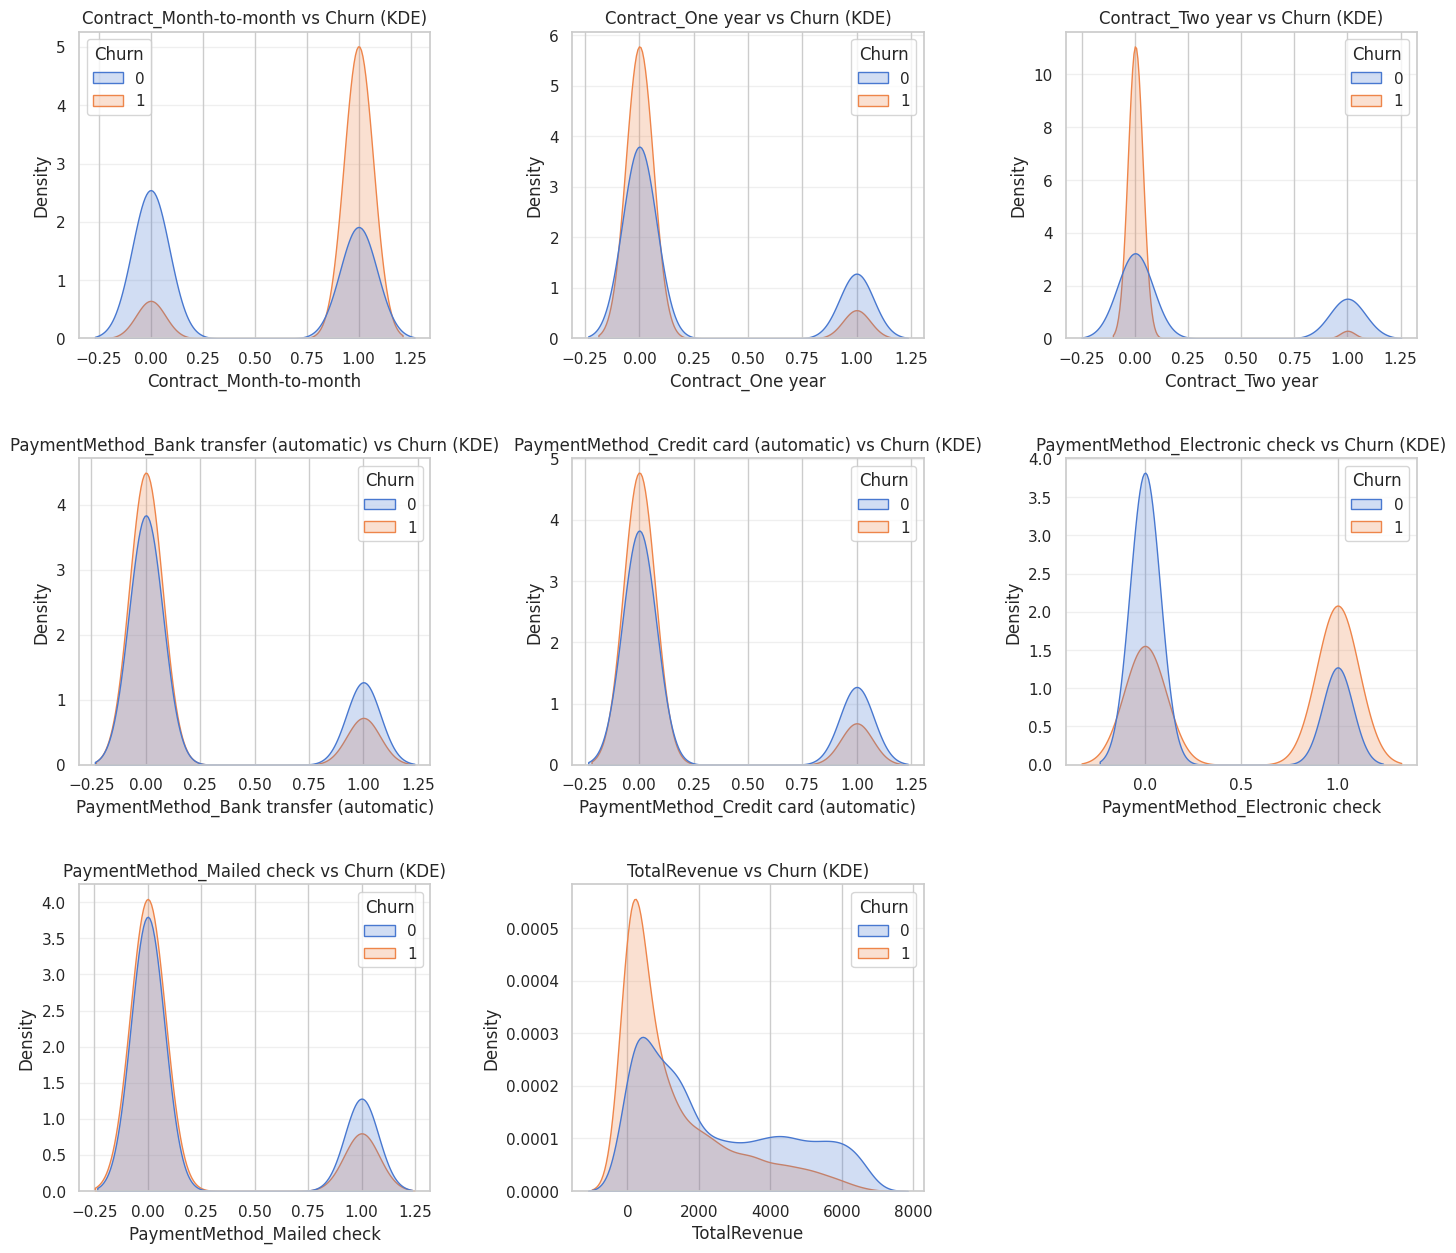

In [ ]:
def _ensure_binary_churn(df, churn_col="Churn"):
    y = df[churn_col]
    if y.dtype == "O":
        mapping = {"Yes": 1, "No": 0, "True": 1, "False": 0, "Ja": 1, "Nee": 0}
        y = y.map(mapping).astype("Int64")
    return y.astype(int)

def _plot_numeric(ax, df, col, churn_col="Churn"):
    sns.kdeplot(data=df, x=col, hue=churn_col, common_norm=False, fill=True, ax=ax)
    ax.set_title(f"{col} vs {churn_col} (KDE)")
    ax.grid(True, axis="y", alpha=0.3)

def _plot_categorical(ax, df, col, churn_col="Churn", max_levels=15):
    vc = df[col].value_counts(dropna=False)
    keep = set(vc.head(max_levels).index)
    df2 = df[df[col].isin(keep)].copy()
    df2[col] = df2[col].astype("object").fillna("(Missing)")

    temp = (df2.groupby([col, churn_col]).size()
              .groupby(level=0).apply(lambda s: s/s.sum())
              .reset_index(name="pct"))
    pivot = temp.pivot(index=col, columns=churn_col, values="pct").fillna(0)
    # sort churn=1 if present, otherwise final column
    sort_col = 1 if 1 in pivot.columns else pivot.columns[-1]
    pivot = pivot.sort_values(by=sort_col, ascending=False)
    pivot.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(f"{col} vs {churn_col} (proportions)")
    ax.set_ylabel("Share")
    ax.set_xlabel(col)
    ax.grid(True, axis="y", alpha=0.3)

def plot_all_vars(df, churn_col="Churn", per_page=9, ncols=3, max_levels_cat=15):
    df = df.copy()
    df[churn_col] = _ensure_binary_churn(df, churn_col)

    feature_cols = [c for c in df.columns if c != churn_col]
    num_cols = [c for c in feature_cols if is_numeric_dtype(df[c])]
    cat_cols = [c for c in feature_cols if not is_numeric_dtype(df[c])]
    all_cols = num_cols + cat_cols
    if not all_cols:
        print("No vars to plot.")
        return

    n = len(all_cols)
    for start in range(0, n, per_page):
        batch = all_cols[start:start+per_page]
        rows = int(np.ceil(len(batch) / ncols))
        fig, axes = plt.subplots(rows, ncols, figsize=(5*ncols, 4.6*rows))
        axes = np.array(axes).ravel() if isinstance(axes, np.ndarray) else np.array([axes])

        for ax in axes:
            ax.set_visible(False)

        for i, col in enumerate(batch):
            ax = axes[i]
            ax.set_visible(True)
            dcol = df[[col, churn_col]].copy()
            try:
                if is_numeric_dtype(df[col]):
                    valid = dcol[col].notna() & dcol[churn_col].notna()
                    dplot = dcol.loc[valid]
                    if dplot[col].nunique() > 1:
                        _plot_numeric(ax, dplot, col, churn_col)
                    else:
                        ax.text(0.5, 0.5, f"{col}\n(weinig variatie)", ha="center", va="center")
                        ax.set_axis_off()
                else:
                    if dcol[col].isna().any():
                        dcol[col] = dcol[col].astype("object").fillna("(Missing)")
                    _plot_categorical(ax, dcol, col, churn_col, max_levels=max_levels_cat)
            except Exception as e:
                ax.text(0.5, 0.5, f"Kon {col} niet plotten:\n{e}", ha="center", va="center")
                ax.set_axis_off()

        plt.tight_layout(pad=3.0)
        fig.subplots_adjust(top=0.92, bottom=0.08)
        plt.show()

# --- Caller ---
plot_all_vars(churn)

#### Correlation Heatmap of numerical variables

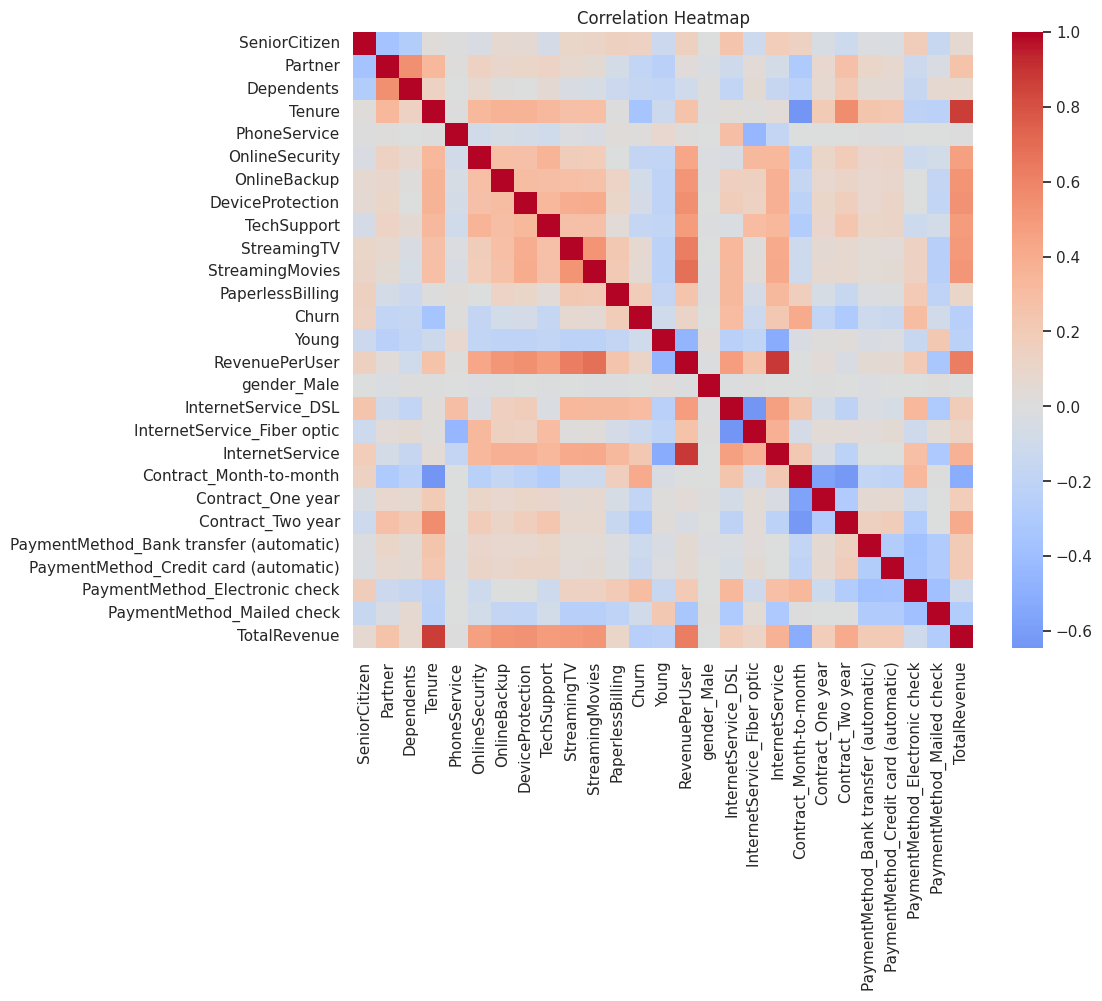

In [ ]:
plt.figure(figsize=(10,8))
corr = churn.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

#### Radar Plot

Below we provide some hint steps to generate a radar plot that will show us which variables **deviate from the average** in terms of churn.

Quite often some visualizations can already deliver interesting insights!


In [ ]:

# standardize all variables to make the plot more interpretable
standardized = (churn - churn.mean()) / churn.std()

# calculate the average values for churners and non-churners
# we add +1 because the radar plot can only plot positive values
standardized_churn = standardized[churn.Churn == True].drop("Churn", axis=1).mean() +1
standardized_no_churn = standardized[churn.Churn == False].drop("Churn", axis=1).mean() +1

# Combine the datasets into a single DataFrame for plotting
polar_data = pd.DataFrame({
    'Category': standardized_churn.index.tolist(),  # Categories from the index
    'Churn': standardized_churn.values,
    'No Churn': standardized_no_churn.values
})

# Melt the DataFrame to a long format suitable for Plotly Express
polar_data = polar_data.melt(id_vars='Category',
                       value_vars=['Churn', 'No Churn'],
                       var_name='Line',
                       value_name='Value')

# Create the polar chart
fig = px.line_polar(
    polar_data,
    r='Value',           # Radius
    theta='Category',    # Angular axis
    color='Line',        # Different lines for 'Standardized True' and 'Standardized False'
    line_close=True,     # Close the line in the polar plot
    template='plotly_white'  # Use a clean background template
)

# Update layout for better visualization
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, max(polar_data['Value']) + 0.1]  # Adjust range to fit the data
        )
    ),
    legend_title_text="Churn Status"
)

# Show the plot
fig.show()

From this plot, we can already infer that having a **month-to-month contract**, the kind of **internet service** and paying with **electronic checks** will be strong indicators of whether a client will churn or not.

## Train Model

#### Train-Test Split

We perform a train-test split to evaluate the model's performance on unseen data, ensuring it generalizes well to new examples. We fit our model and learn patterns from the data in the train set, and evaluate its performance on the test set.

In [ ]:
# Separate features (X) and target (y)
X = churn.drop(columns=["Churn"])
y = churn["Churn"]

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% goes to the test set
    stratify=y,         # keeps churn ratio equal in both sets
    random_state=42     # ensures the result is reproducible
)

# ==========================
# Check split results
# ==========================
print("✅ Train/Test Split Completed\n")

print("Total samples:", len(churn))
print("Training samples:", len(X_train), f"({len(X_train)/len(churn)*100:.1f}%)")
print("Testing samples:", len(X_test), f"({len(X_test)/len(churn)*100:.1f}%)\n")

print("Churn distribution in TRAIN set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nChurn distribution in TEST set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))



✅ Train/Test Split Completed

Total samples: 7041
Training samples: 4928 (70.0%)
Testing samples: 2113 (30.0%)

Churn distribution in TRAIN set (%):
Churn
0    73.48
1    26.52
Name: proportion, dtype: float64

Churn distribution in TEST set (%):
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


### Logistic Regression vs Random Forest
<br>

<left>
<img src="https://www.dropbox.com/scl/fi/viqzaerfrge7hiqohc9jt/logistic-vs-random-forest.png?rlkey=bryllwey8eqomhrhcsjgjvnkq&raw=1" width="50%" style="float:left">
  
<br>
    <br>
<right>
<img src="https://www.dropbox.com/scl/fi/a7ildp1qp7ylbd7bkgjrj/random-forest-classifier.jpg?rlkey=mh471ihmo49x84s3vhn6ti513&raw=1" width="50%" style="float:right">

### Logistic Regression

Logistic regression is a statistical model used for binary classification problems. It predicts the probability of an outcome belonging to one of two classes (e.g., churn or no churn) by applying a sigmoid function to a linear combination of input features, producing values between 0 and 1.

In [ ]:
#Write the code to apply Logistic Regression
logit = LogisticRegression(random_state=42)

# fit the classifier on the training data
logit.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_log = logit.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1553
           1       0.65      0.57      0.60       560

    accuracy                           0.80      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.80      0.80      0.80      2113



How do we now evaluate how well these models perform?

#### Our Different Scoring Metrics

- **accuracy**: $\frac{tp+tn}{tp+tn+fp+fn}$
    - proportion of correctly classified instances
    
<br>

- **precision**: $\frac{tp}{tp+fp}$
    - proportion of predicted instances that truly belongs to that class
    
<br>

- **recall**: $\frac{tp}{tp+fn}$
    - proportion of actual instances of a class correctly classified


#### **Types of Errors on our Churn case**
If *accuracy* assumes that both errors (False Positive (FP) and False Negative (FN) are as important, *is this appropriate for our case?*

**Probably not:** Cost FP (cost of retention incentive)  << cost FN (cost of losing a customer)

<br>
<img  align="center" src="https://www.dropbox.com/s/oedtx2hhjxg7g5l/example.PNG?raw=1"/>
<br>

Our model achieves an overall accuracy of 80%, which initially seems good. However, accuracy alone can be misleading in an imbalanced setting like churn prediction.
- For non-churners (class 0), the model performs very well — with high precision (0.85) and high recall (0.89). This means most customers predicted to stay indeed stay, and most actual non-churners are correctly identified.
- For churners (class 1), performance is weaker — precision (0.64) means that about two out of three customers predicted to churn actually do, while recall (0.56) means the model correctly identifies only a bit more than half of all churners.


#### Confusion Matrix <br>

A confusion matrix summarizes the performance of a classification model by showing the number of correct and incorrect predictions for each class. From these values, we can calculate important metrics like accuracy, precision, recall, and F1 score, providing a comprehensive evaluation of model performance.

<center>
<img src="https://www.dropbox.com/s/3a9xp1dtfspfqxw/confusion%20matrix.PNG?raw=1" height=40% width=40%/>

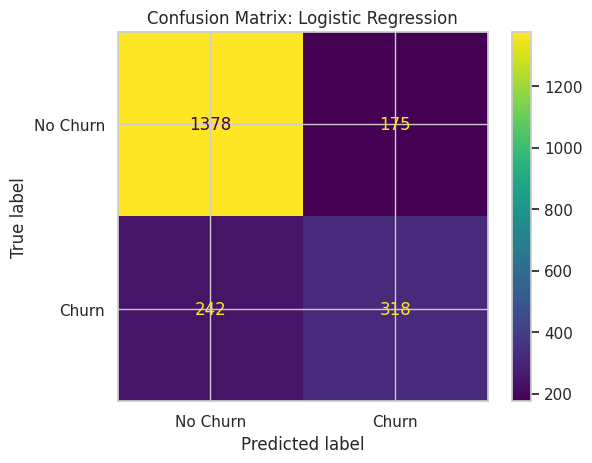

In [ ]:
# Provide the code for the output confusion matrix for the logistic regression (metrics.confusion_matrix)
cm = confusion_matrix(y_test, y_pred_log)

# Display the confusion matrix using Matplotlib
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

#### Are we happy with this result?

1️⃣ We are good at predicting who will stay.
✅ Our model correctly identifies most of the customers who are not likely to churn.
➡️ This means it has high accuracy on the majority class (non-churners), which is often the largest group.

2️⃣ We are not as good at predicting who will leave.
⚠️ Because churners are a smaller group (minority class), the model may miss many of them —
even if overall accuracy looks high.
➡️ That’s why we must look beyond accuracy and use more meaningful metrics like recall, precision, and F1-score.

3️⃣ Which misclassification matters most for the business?
💡 This depends on your business goal:

**Recall (Sensitivity):**

- Of all the actual churners, how many did we correctly identify?

Important if the goal is to catch as many churners as possible,
e.g., to send them retention offers before they leave.

**Precision:**

- Of all the customers we predicted to churn, how many actually churned?

Important if the goal is to avoid wasting resources on customers who would have stayed anyway.


#### Imbalance in data

What can you do in case of imbalance?

You can over-sample the minority class using:
- **Resampling** where you duplicate observations from your minority class in your training set.
  - Simply adding duplicate records of minority class often don’t add any new information to the model
- **SMOTE** where you synthesize new instances from the existing minority observations in your training set

<center> <img src="https://www.dropbox.com/scl/fi/4qz93kz93pqt72rmldy5p/smote.png?rlkey=xs5m4sqn7v8jch07gkutnfmm5&raw=1" width="70%" style="float:center">

#### Treating the data imbalance


In [ ]:
#we make sure that our training dataset is balanced (Apply SMOTE only to the training set)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


print("Original dataset shape:", y_train.value_counts())

print("Resampled dataset shape:", y_train_res.value_counts())


Original dataset shape: Churn
0    3621
1    1307
Name: count, dtype: int64
Resampled dataset shape: Churn
0    3621
1    3621
Name: count, dtype: int64


SMOTE only acts on your training set.
You **NEVER** oversample the test set because that would distort the true class distribution and make evaluation unrealistic.

By default, SMOTE balances the minority and majority classes 50/50.
But you can easily change that using the *sampling_strategy* parameter. This does not guarantee better results, however, as it depends on the data and context of the case.

In [ ]:
#Write the code to apply Logistic Regression
logit = LogisticRegression(random_state=42)

# fit the classifier on the training data
logit.fit(X_train_res, y_train_res)

# Use the classifier to predict the target on the test set
y_pred_log = logit.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1553
           1       0.56      0.68      0.61       560

    accuracy                           0.77      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.77      0.78      2113



#### Feature Importance in Logistic Regression
Logistic regression quantifies feature importance using its **coefficients**, which represent both the strength and direction of each feature's relationship with the target. This provides a distinct advantage: not only can we determine **how strongly** a feature influences the outcome, but we can also understand whether its effect **increases or decreases** the likelihood of the target event (e.g., churn).

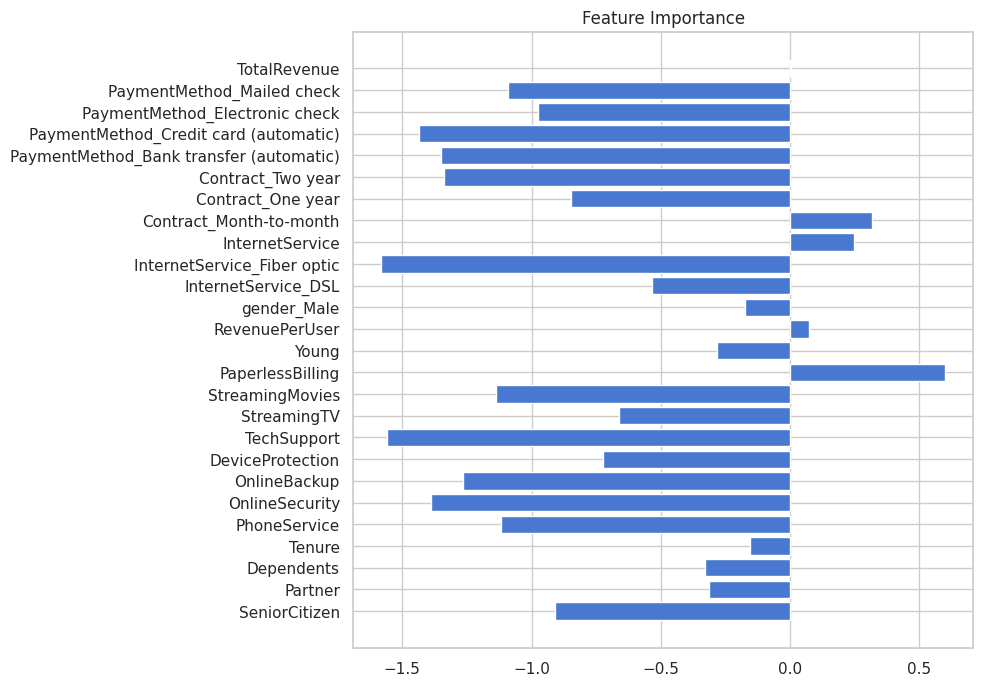

In [ ]:
importance = pd.Series(logit.coef_[0], index=X_train_res.columns)

fig = plt.figure(figsize = (8,8))
plt.barh(X_train_res.columns, importance)
plt.title('Feature Importance')
plt.show()

The x-axis shows the strength and direction of each feature’s relationship with churn probability.
- Positive values (right side) → increase churn likelihood.
- Negative values (left side) → decrease churn likelihood (i.e., more likely to stay).

The longer the bar, the stronger the effect.


### Decision Tree

<img  align="right" src="https://www.dropbox.com/s/jl6ypj1cg08akvt/tree3.PNG?raw=1"/>
<br>

A decision tree is a predictive model that splits data into subsets based on the most important features at each step. The goal is to **create groups (leaves) that are as "pure" as possible**, meaning each leaf ideally contains data points from only one class (e.g., all churners or all non-churners).




#### Training a Decision Tree

The tree is grown step by step:

1. **Identify the Most Discriminative Features**:

  - At each level of the tree, the algorithm evaluates all available features to find the one that best separates the data into distinct classes.
  - A "split" is determined by identifying the best value of the feature to divide the data.
2. **Make Splits to Maximize Purity**:
  - The tree seeks to maximize the purity of each resulting group after a split. Purity means that the data in each group belongs mostly (or entirely) to one class.
  - For example, a split might divide people into groups such that one group contains mostly churners and the other contains mostly non-churners.
3. **Stop Splitting When Necessary**:
  - Splits continue until stopping criteria are met, such as reaching a maximum depth, having too few samples in a node, or achieving perfect purity.

By repeatedly applying these steps, the decision tree creates a structure where each path from the root to a leaf represents a sequence of decisions that leads to a prediction. The resulting model is both intuitive and interpretable, making it a powerful tool for classification and regression tasks.
<img  align="right" src="https://www.dropbox.com/s/srxvaem3xii0624/tree8.PNG?raw=1" width=100%/>


#### Measuring Impurity
<br>
<div style="float:right">
  <img src="https://www.dropbox.com/scl/fi/lx3vmmq0qc3sk1od8inqa/Impurity.png?rlkey=27vx0xd6vp5xwgrw1h6mmxw5j&raw=1" width="50%"/>
</div>
The decision tree uses an impurity measure to assess the quality of splits. Common impurity metrics include:

- **Gini Impurity**: Measures how mixed the classes are within a group. Lower Gini impurity indicates greater purity.
- **Entropy**: Quantifies the uncertainty in a group. Lower entropy means higher certainty (purity).


We select the split that results in the greatest purity gain.

<img  align="left" src="https://www.dropbox.com/scl/fi/4vrreaq378owew12uny0u/tree5.PNG?rlkey=1y3mn35jld1m0vgdvripr9mcx&raw=1" width=50% />
<img  align="right" src="https://www.dropbox.com/s/raosuvle9dri8o7/tree6.PNG?raw=1" width=44%/>

#### Fit Decision Tree on Original Dataset

In [ ]:
#Write the code to apply Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# fit the classifier on the training data
dt.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_log = dt.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1553
           1       0.50      0.47      0.48       560

    accuracy                           0.73      2113
   macro avg       0.65      0.65      0.65      2113
weighted avg       0.73      0.73      0.73      2113



#### Fit Decision Tree on Over-sampled Dataset

In [ ]:
#Write the code to apply Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# fit the classifier on the training data
dt.fit(X_train_res, y_train_res)

# Use the classifier to predict the target on the test set
y_pred_log = dt.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1553
           1       0.49      0.53      0.51       560

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113



Over-sampling the minority class (churn) does not improve our results by a lot. Decision Trees are non-parametric models that can create very fine splits. When you oversample with SMOTE:
- You’re adding synthetic points near minority class boundaries.
- But the tree can easily overfit those synthetic samples, especially if it’s deep.

→ You may end up with higher training accuracy but little test improvement.

#### Overfitting

<img  align="right" src="https://www.dropbox.com/scl/fi/mlqbrk33i6op9e58qcoze/BiasvarianceCornell.png?rlkey=1xf8f8gyob0kyhruphe4bezdo&raw=1" width=47%/>

Overfitting occurs when a machine learning model learns **patterns specific to the training data**, including noise or outliers, rather than capturing generalizable patterns. As a result, the model performs exceptionally well on the training set but **struggles to generalize to unseen data**, resulting in poor performance on the test set.



#### Avoiding overfitting

<img  align="right" src="https://www.dropbox.com/scl/fi/728u2can2qcnd2t3bql2u/Overfitting_min_samples_leaf.png?rlkey=nourijc2b34is0j0yo7us3btp&raw=1" width=50%/>

**Hyperparameter tuning** helps improve the model’s performance and generalization by controlling its complexity. Common hyperparameters for decision trees include:
- **Maximum tree depth** (`max_depth`):  Limits how deep the tree can grow to prevent overfitting to the training data.
- **Minimum samples per leaf** (`min_samples_leaf`): Ensures that leaf nodes have a minimum number of samples, avoiding splits that create overly specific branches.
- **Maximum leaf nodes** (`max_leaf_nodes`): Restricts the total number of leaf nodes, simplifying the tree structure.


#### Pruning the Tree

Pruning the tree (i.e., limiting how deep or specific the tree becomes) helps to avoid overfitting (on the majority class):
- It prevents the model from creating too many small, overly specific splits.
- It forces the tree to focus on the most important, generalizable patterns.
- It reduces variance (overfitting), even if bias slightly increases.


We can check the depth of the current tree:

In [ ]:
DTdepth = dt.get_depth()
DTdepth

27

In [ ]:
#Write the code to apply Logistic Regression
dt = DecisionTreeClassifier(random_state=42, max_depth = 5)

# fit the classifier on the training data
dt.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_dt = dt.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1553
           1       0.61      0.57      0.59       560

    accuracy                           0.79      2113
   macro avg       0.73      0.72      0.72      2113
weighted avg       0.78      0.79      0.79      2113



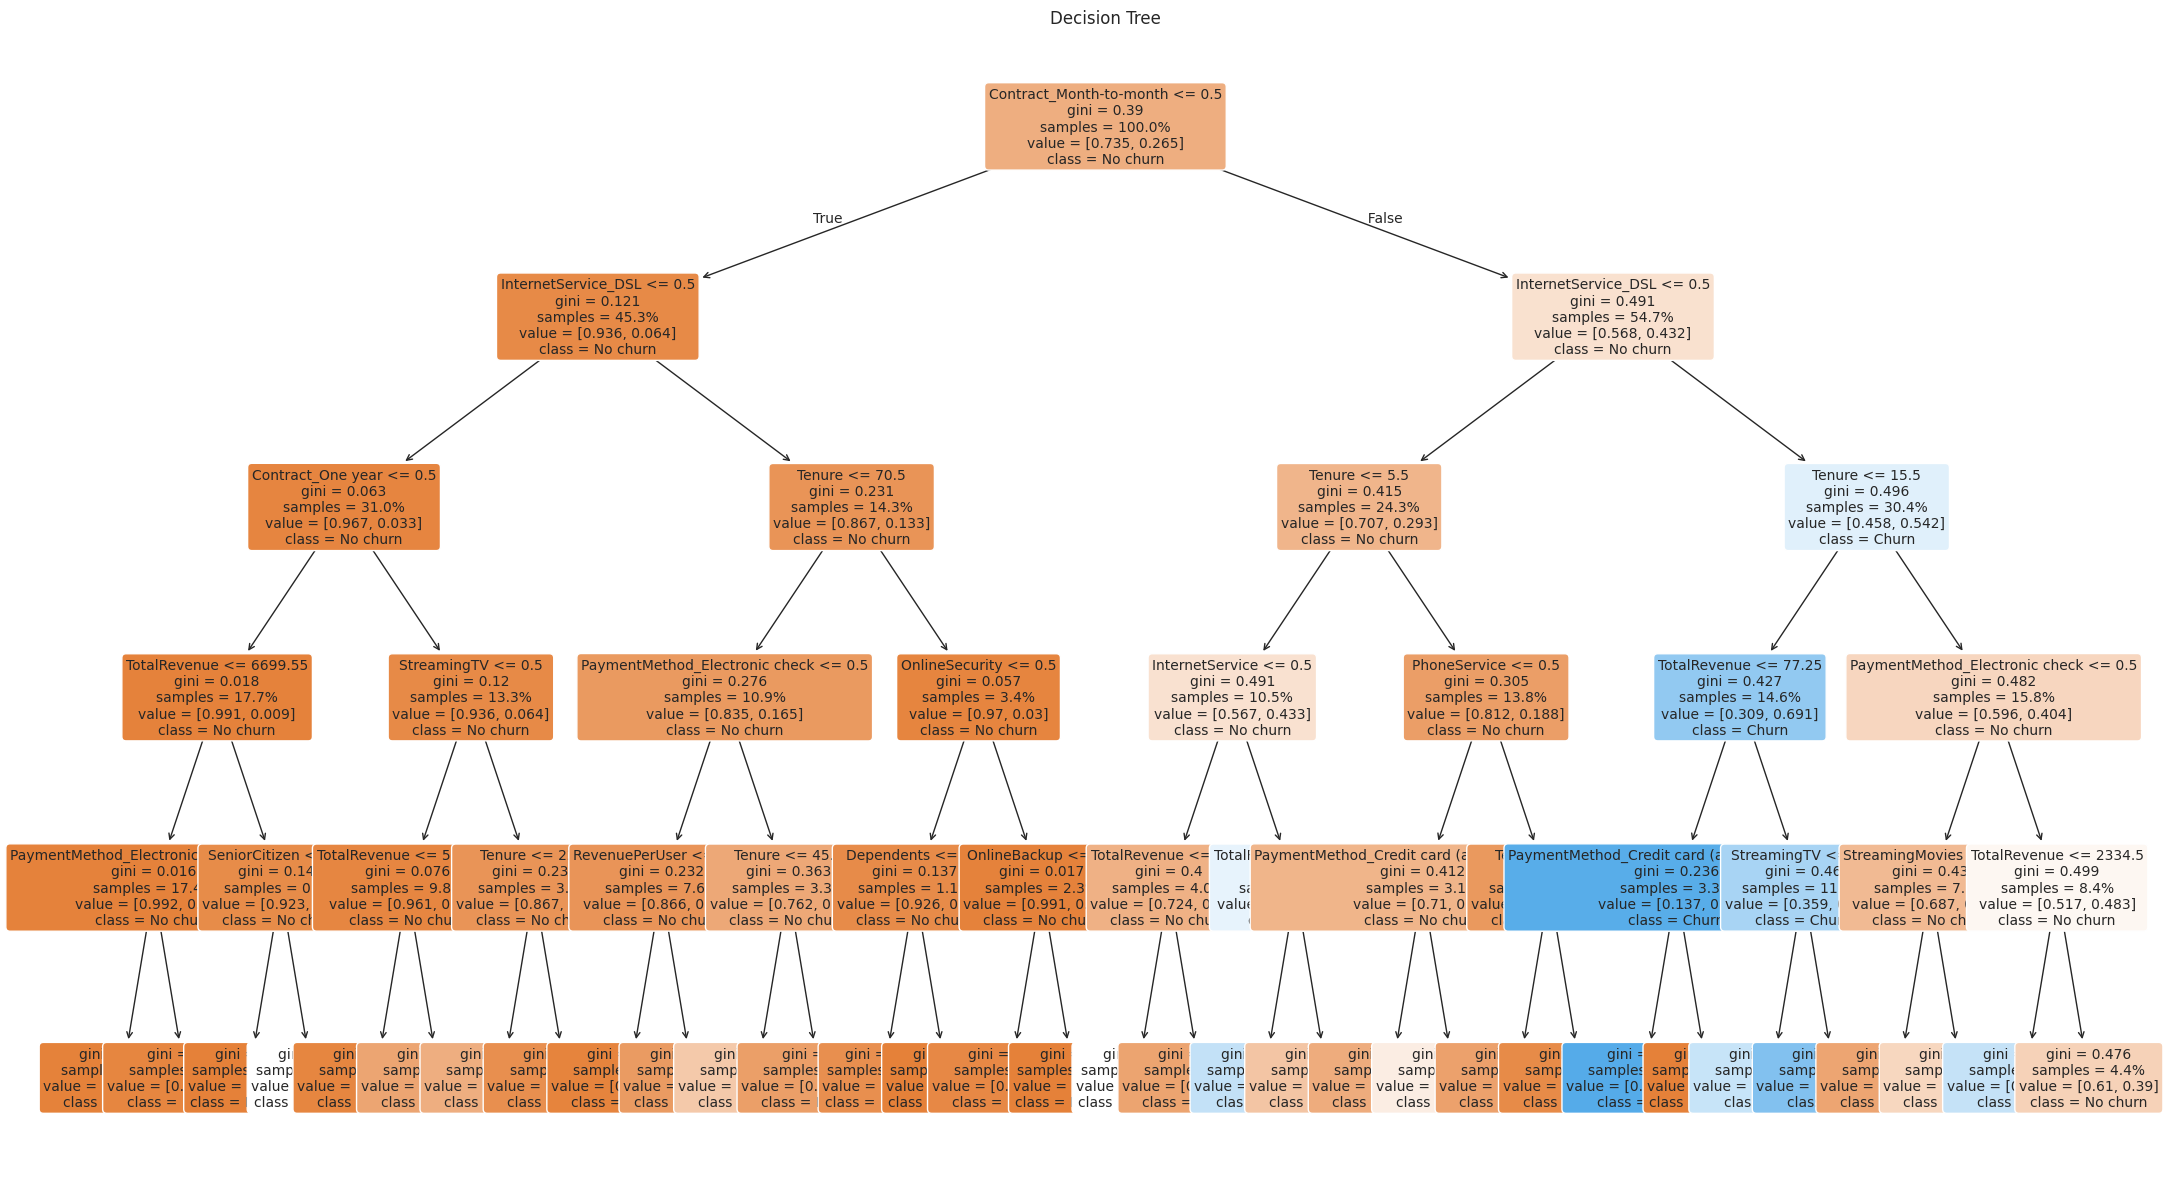

In [ ]:
#### Visualizing the Tree
plt.figure(figsize=(22, 12))  # make it wide enough to read
tree.plot_tree(
    dt,
    feature_names=list(X_train.columns),
    class_names=['No churn','Churn'],
    filled=True,
    rounded=True,
    proportion=True,   # show class proportions per node
    impurity=True,     # show Gini/entropy depending on your criterion
    fontsize=10
)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

By setting *max_depth* = 5, we already get a better performance. Let's now apply a grid search to find the optimal combination of parameters for our decision tree. Check out the documentation on <a href= https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html>`DecisionTreeClassifier`</a> to find which parameters can be optimized.


#### GridSearch CV
<img  align="right" src="https://www.dropbox.com/scl/fi/6t8av6alsjqxtl8ufxol0/Crossvalidation.jpg?rlkey=ycunvm0i2851atj79lzde2846&raw=1" width=40%/>

**Grid Search**
- An exhaustive search over all combinations of specified hyperparameter values for a model.
- Tests every possible combination to identify the **best set of hyperparameters**.

**Cross-Validation**
- A robust technique for tuning hyperparameters and evaluating models without relying on a single data split.
  - Maximizes the use of data for training and validation.
  - Particularly useful for imbalanced datasets (like churn) by ensuring every subset of data is used for both training and validation.
- Instead of using a fixed **held-out set**, the training data is split into **k smaller sets (folds)**:
  - **k-1 folds** are used for training.
  - The remaining fold is used for validation.
  - This process is repeated **k times**, each time using a different fold for validation.
- The final performance is measured as the **average across all folds**.


The following code may run for a while due to the size of the parameter grid and cross-validation. You can reduce runtime by shrinking the parameter grid, using fewer CV folds (e.g., 3 instead of 5) or using *HalvingGridSearchCV* (aggressive early pruning of bad configs) or *RandomizedSearchCV*.

In [ ]:
base_dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 4, 5, 6, 8, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_leaf_nodes": [None, 10, 20, 50],
    "class_weight": [None, "balanced"],
}

# ----- 2) Cross-validation & scoring -----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pick your main metric; for imbalanced classes, "f1" or "roc_auc" are solid choices
grid = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    scoring="f1",           # change to "roc_auc" if you prefer AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True              # refit best model on the full training set (by scoring metric)
)

# ----- 3) Run the grid search -----
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# ----- 4) Evaluate on test set -----
best_dt = grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 3072 candidates, totalling 15360 fits
Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.6198357026565731

Classification report (test):
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1553
           1       0.51      0.78      0.61       560

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.74      0.75      2113



#### Feature Importance in Decision Trees
When we plot a decision tree, we can observe how the model splits the data based on the most important features at each step:

- Features used near the top of the tree (closer to the root) generally have a greater influence on predictions because they affect a larger portion of the data.
- This visualization provides a local perspective on how individual features impact specific splits.

**Calculate Feature Importance**

- Feature importance is determined by how much each feature reduces impurity (e.g., Gini impurity or entropy) across all splits in the tree.
- In Scikit-learn, the importance values are stored in the attribute `feature_importances_`.
- These are computed as the mean and standard deviation of the accumulated impurity decrease across all splits where the feature is used.


**Caution: High Cardinality Features**
While impurity-based feature importance is commonly used, it can be misleading for features with high cardinality (i.e., features with many unique values). High cardinality features often appear artificially important because they can create many splits, even if they don’t provide meaningful predictive power.


In [ ]:
#Get importance
importance = best_dt.feature_importances_
#Summarize feature importance
for i,v in enumerate(importance):
    print('Feature: ',X_train.columns[i],', Score: ',importance[i].round(4))

Feature:  SeniorCitizen , Score:  0.0
Feature:  Partner , Score:  0.0
Feature:  Dependents , Score:  0.0
Feature:  Tenure , Score:  0.1313
Feature:  PhoneService , Score:  0.0
Feature:  OnlineSecurity , Score:  0.0
Feature:  OnlineBackup , Score:  0.0
Feature:  DeviceProtection , Score:  0.0
Feature:  TechSupport , Score:  0.0
Feature:  StreamingTV , Score:  0.0
Feature:  StreamingMovies , Score:  0.0
Feature:  PaperlessBilling , Score:  0.0
Feature:  Young , Score:  0.0
Feature:  RevenuePerUser , Score:  0.0
Feature:  gender_Male , Score:  0.0
Feature:  InternetService_DSL , Score:  0.1402
Feature:  InternetService_Fiber optic , Score:  0.0
Feature:  InternetService , Score:  0.0
Feature:  Contract_Month-to-month , Score:  0.7167
Feature:  Contract_One year , Score:  0.0
Feature:  Contract_Two year , Score:  0.0118
Feature:  PaymentMethod_Bank transfer (automatic) , Score:  0.0
Feature:  PaymentMethod_Credit card (automatic) , Score:  0.0
Feature:  PaymentMethod_Electronic check , Sco

In [ ]:
# Provide a histogram of the feature importances for the decision tree
fig = px.histogram(x=X_train.columns, y=importance,height=500,title="Decision Tree: Feature importance based on impurity",labels={
                     "x": "Feature",
                     "y": "Importance",
                 },)
fig.update_traces(marker_line_color='black', marker_line_width=2)
fig.show()

### Ensemble Models

Thus far, we’ve explored logistic regression and decision trees as standalone models. However, both models have their limitations:

- Logistic regression assumes linear relationships, which may oversimplify complex patterns in the data.
- A single decision tree can overfit the training data and may not generalize well.

To overcome these limitations, we turn to ensemble methods like Random Forest and XGBoost. These models combine multiple trees to improve predictive performance and robustness:
- an **ensemble** is a group of weak predictors
- **Random Forest** reduces overfitting by averaging predictions from multiple decision trees trained on different subsets of data and features.
- **XGBoost** uses a boosting approach to sequentially correct errors from previous models, creating a strong learner from a series of weak learners.

By leveraging these ensemble methods, we can capture more complex relationships and achieve **greater predictive power**, while maintaining generalization.

#### Random Forest

Random Forest is an ensemble learning method that combines the predictions of multiple decision trees to improve accuracy and generalization. It introduces two key innovations to enhance performance:

**Bagging (Bootstrap Aggregating)**:
- Each tree in the forest is trained on a random subset of the training data, sampled with replacement.
- This reduces overfitting by ensuring that no single tree dominates the model.

**Random Attribute Sampling**:
- When splitting a node, Random Forest selects the best feature to split on, but only from a random subset of features, rather than evaluating all features.
- This introduces additional randomness, making the trees in the forest more diverse.

##### On Original Dataset

In [ ]:
#Write the code to apply Random Forrest
rf = RandomForestClassifier(random_state=42)

# fit the classifier on the training data
rf.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_rf= rf.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1553
           1       0.60      0.50      0.55       560

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



##### On Over-sampled Dataset

In [ ]:
#Write the code to apply Random Forrest
rf = RandomForestClassifier(random_state=42)

# fit the classifier on the training data
rf.fit(X_train_res, y_train_res)

# Use the classifier to predict the target on the test set
y_pred_rf= rf.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1553
           1       0.56      0.57      0.56       560

    accuracy                           0.77      2113
   macro avg       0.70      0.70      0.70      2113
weighted avg       0.77      0.77      0.77      2113



Ensemble models like Random Forests are already robust to imbalance and noise and generalize much better because they combine many different trees. That is why over-sampling the training set does not necessarily improve performance by a large margin.

A better solution is to use cross-validation within a grid search to tune the model’s hyperparameters. This approach ensures that the model’s performance is evaluated across multiple folds, leading to a more reliable estimate of generalization and reducing the risk of overfitting to any single partition of the data.

In [ ]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator = rf,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'class_weight': 'balanced_subsample', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 400}
Best F1: 0.6398031992308308


In [ ]:
# Evaluate on test set
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_rf))


Classification report (test):
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1553
           1       0.54      0.75      0.63       560

    accuracy                           0.76      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.76      0.77      2113



#### XGBoost


<strong>Boosting</strong> = train predictors sequentially, each trying to correct its predecessor.
    
- Iteratively reweight the training distribution according to the classification error (or other loss function).
- Misclassified cases get a higher weight.
- Correctly classified cases get a lower weight.
<br><strong>⇒ Difficult observations get more attention!</strong>

<strong>Gradient boosting</strong>: a tree in the ensemble is fit to the residual of the prediction from the earlier trees.
<br><strong>XGBoost</strong>: Optimization of Gradient Boosting, highly efficient, flexible and portable.
<br>

<img  align="left" src="https://www.dropbox.com/scl/fi/s2qnj8vwm4696yel1iffy/boosting.png?rlkey=2bt3nsgddo3hlvorrrrdf4mvt&raw=1" width=50%/>
<br>
<img  align="right" src="https://www.dropbox.com/scl/fi/ccqlt08se5wsfzqtjlqou/boosting2.png?rlkey=xi64mom4kavhxjanq06ddtipm&raw=1" width=45%/>


-

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_xgb= xgb.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1553
           1       0.59      0.54      0.56       560

    accuracy                           0.78      2113
   macro avg       0.71      0.70      0.71      2113
weighted avg       0.77      0.78      0.77      2113



But you can also explicitly weight the classes

In [ ]:

xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # imbalance ratio
)
xgb.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_xgb= xgb.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1553
           1       0.52      0.70      0.60       560

    accuracy                           0.75      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.78      0.75      0.76      2113



By adding even more parameters using a grid search, you can improve the performance even more. Try it out.


In [ ]:
# Imbalance ratio for XGBoost (pos_weight = negatives/positives)
imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()

xgb = xgb.XGBClassifier(
        learning_rate=0.05, n_estimators=400, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=imbalance_ratio,
        eval_metric="auc", random_state=42)

xgb.fit(X_train, y_train)

# Use the classifier to predict the target on the test set
y_pred_xgb= xgb.predict(X_test)

# Print evaluation report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1553
           1       0.52      0.76      0.61       560

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



##### Feature Importance XGBoost

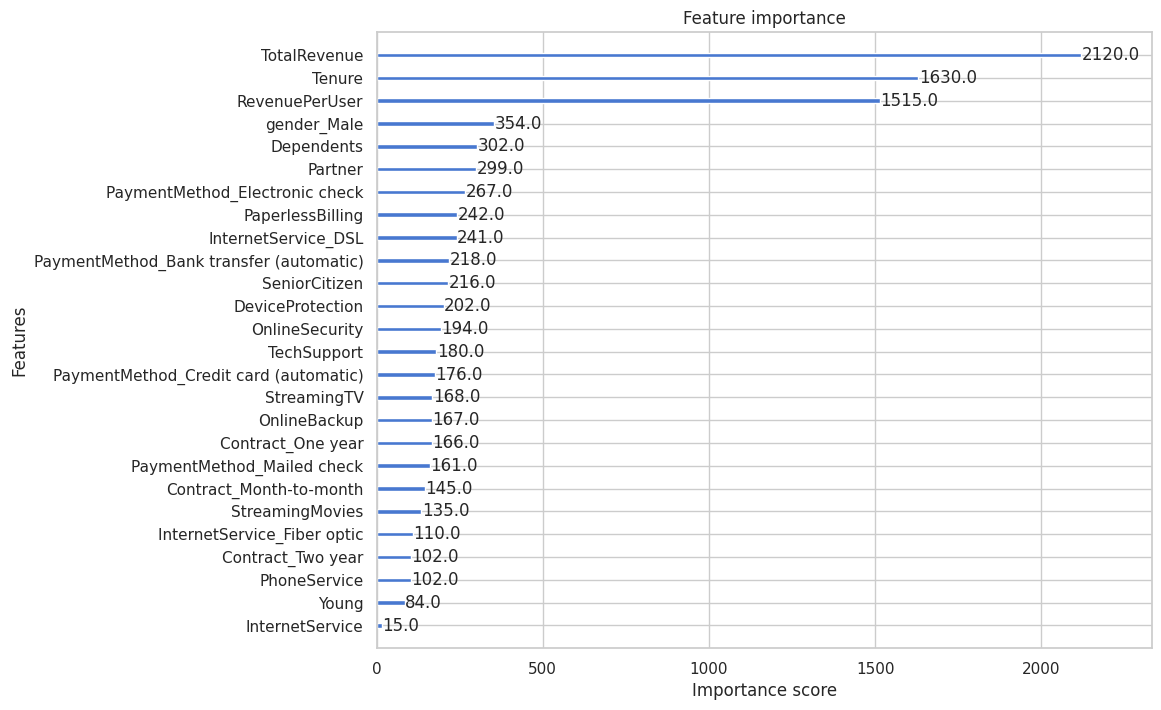

In [ ]:
#Plot importance metrics for classification
#XGBoost is called by xgb_model using plot_importance that utilizes the default argument for importance by ‘weight’
#One could change it to gain by adding an argument importance_type='gain’.
fig, ax = plt.subplots(figsize=(10,8))
plot_importance(xgb, importance_type='weight', ax=ax)
plt.show()

### SHAP Values

In [ ]:
import shap
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)


100%|===================| 4920/4928 [01:27<00:00]       

In [ ]:
shap_values

.values =
array([[-0.00617239,  0.01717097,  0.1211754 , ...,  0.37041712,
         0.10362944, -0.08031349],
       [-0.09192995, -0.05228082, -0.01402324, ..., -0.03736399,
        -0.16853543,  0.58452437],
       [ 0.33572198, -0.00814729, -0.02258471, ..., -0.03849511,
        -0.1948592 ,  0.60374691],
       ...,
       [-0.00310955,  0.02670875,  0.15282919, ..., -0.02885744,
         0.14984265, -0.54697608],
       [-0.05050779,  0.04022431,  0.16533313, ..., -0.05894079,
        -0.4444432 , -0.13723391],
       [-0.0484606 , -0.0203494 , -0.02141384, ...,  0.044598  ,
         0.06207098,  0.22166911]])

.base_values =
array([-1.08205081, -1.08205081, -1.08205081, ..., -1.08205081,
       -1.08205081, -1.08205081])

.data =
array([[0.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 0.000e+00,
        2.044e+03],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        4.640e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        2.

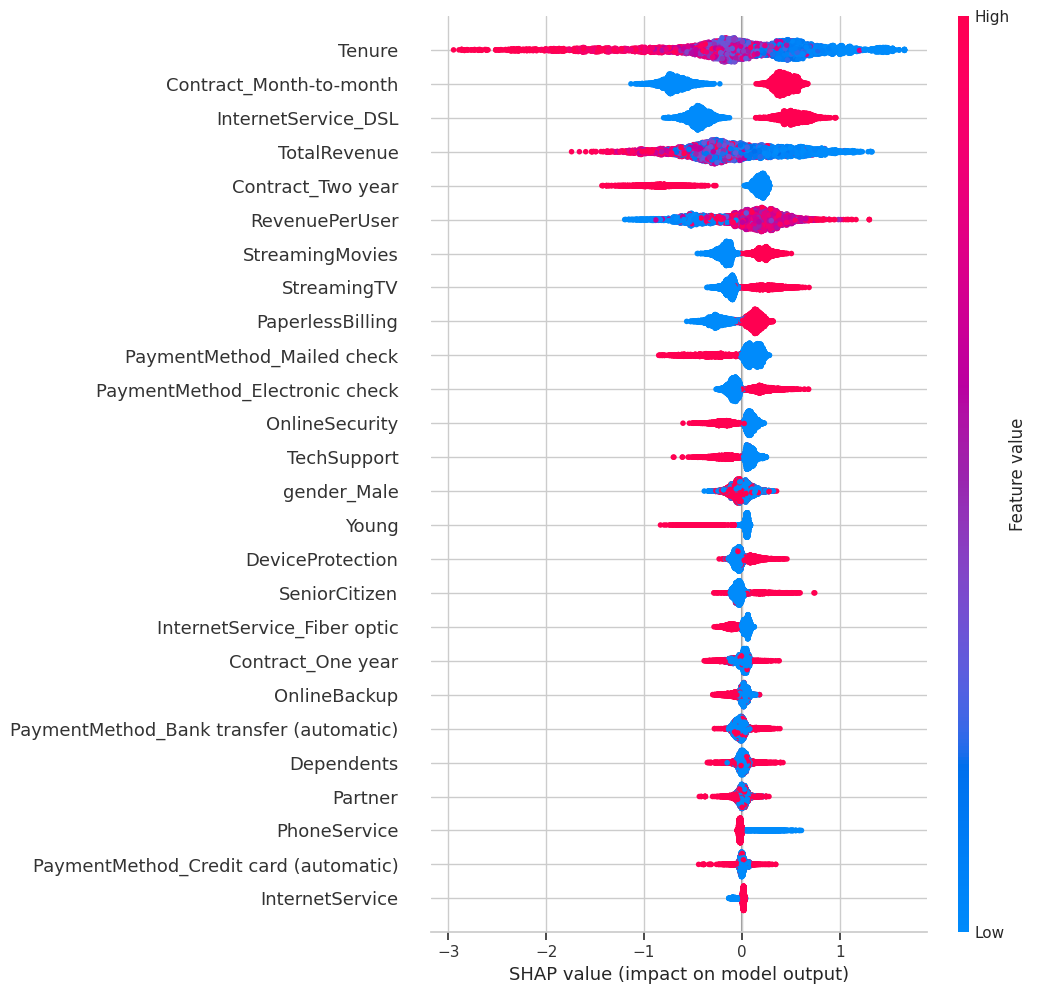

In [ ]:
shap.plots.beeswarm(shap_values, max_display=len(X_train.columns))


#### Why SHAP ≠ XGBoost Feature Importance
**Different measures:**
- plot_importance(..., importance_type='weight') → counts how often a feature is used in splits.
- importance_type='gain' → average improvement in loss when used.
- SHAP → average contribution of each feature to the model’s actual predictions.

**Different units:**
- XGBoost importances are in split/loss units.
- SHAP values are in model output units (log-odds or probabilities).

**Different behavior:**
- XGBoost importances are global and tree-structure dependent.
- SHAP gives local + global explanations, fairly distributing credit even among correlated features.

✅ **Rule of thumb:**

Use gain importances for a rough global view, and SHAP for an interpretable, consistent measure of how features influence predictions.


## Benchmarking Model Performance

In [ ]:
#The classifiers below have been left open intentionally, there are multiple hyperparameters you could tweak.
#If interested, you can also do a loop to look for the optimal settings of YOUR defined hyperparameters.
#Stackoverflow or the documentation files will yield insights!

clfs = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_leaf=5,
        max_leaf_nodes=5,
        class_weight='balanced'
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        class_weight='balanced'
    ),
    "XGBClassifier": xgb.XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        objective='binary:logistic',
        n_jobs=-1
    )
}

In [ ]:
def plot_curve(clfs, X_train, y_train, X_test, y_test, curve_name, ax):
    """
    Plot the ROC / PR curve for a number of classifiers.
    Parameters:
    - clfs: classifiers as a dict.
    - Data comes from the initial df we used in the notebook (before Logistic Regression)
    - X_train, y_train: training dataset.
    - X_test, y_test: test dataset.
    - curve_name: "ROC" or "PR" indicating the type of curve to plot.
    - ax: matplotlib Axes object where the curve will be plotted.
    """
    for clf_name, clf in clfs.items():
        clf.fit(X_train, y_train)
        y_probs = clf.predict_proba(X_test)[:, 1]

        if curve_name == "ROC":
            fpr, tpr, _ = roc_curve(y_test, y_probs)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f'{clf_name} (area = {roc_auc:.2f})')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title('ROC Curve')
        elif curve_name == "PR":
            precision, recall, _ = precision_recall_curve(y_test, y_probs)
            pr_auc = auc(recall, precision)
            ax.plot(recall, precision, lw=2, label=f'{clf_name} (area = {pr_auc:.2f})')
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title('Precision-Recall Curve')
        else:
            raise ValueError("curve_name must be either 'ROC' or 'PR'")
    ax.legend()
    ax.grid(True)

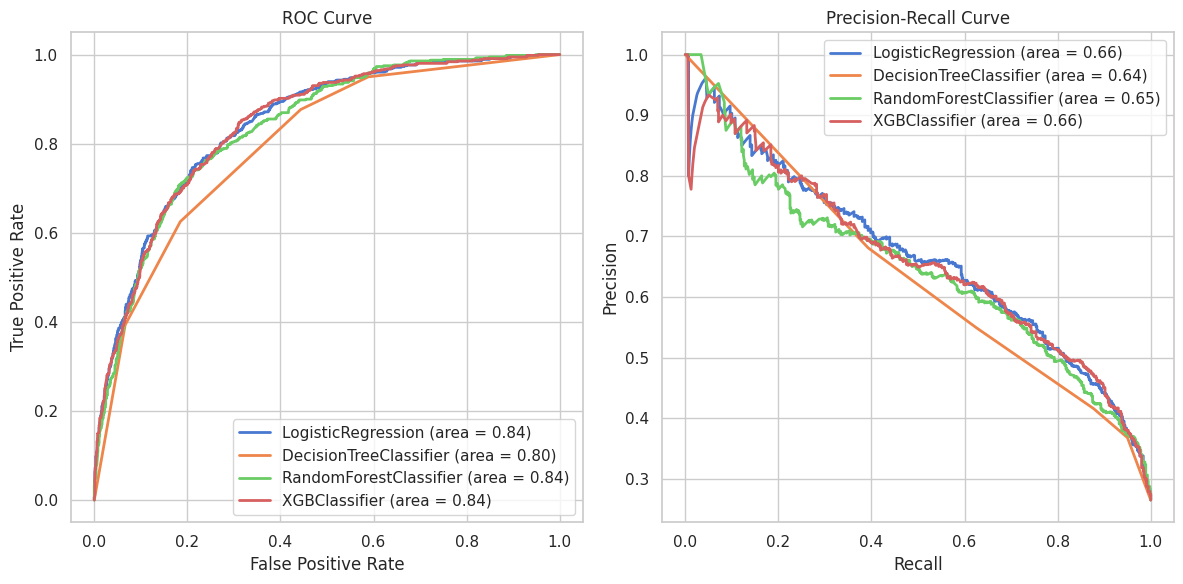

In [ ]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Plot ROC curve on the first subplot
plot_curve(clfs, X_train, y_train, X_test, y_test, "ROC", ax1)
# Plot PR curve on the second subplot
plot_curve(clfs, X_train, y_train, X_test, y_test, "PR", ax2)
plt.tight_layout()
plt.show()

#### ROC vs. Precision-Recall (PR) curve
<img  align="right" src="https://www.dropbox.com/scl/fi/wcqc27aeeo9dnnsicjq1n/pr_roc.png?rlkey=0uk3s8jcgfobfcpqwz26rvr5m&st=ltnscz93&raw=1"/>
<br>
    

**ROC Curve**
- Evaluates a model's ability to distinguish between classes.
- **Sensitivity** (Recall) vs. **1-Specificity** (False Positive Rate) across all thresholds.
- Suited for **balanced classes** or when both positive and negative classes are **equally important**.
- Provides a holistic view of the model's performance across thresholds.


**Precision-Recall (PR) Curve**
- Focuses on the trade-off between Precision and Recall:
  - **Precision**: How many predicted positives are actual positives?
  - **Recall**: How many actual positives are correctly predicted?
- Suited for **imbalanced datasets**, or when the positive class is **more critical** (e.g., predicting churn).

















## Final Takeaways

**Goal Achieved: Predicting Customer Churn**
- The primary objective was to build a model to **predict whether a customer will churn or stay**, enabling proactive intervention strategies.
This process involved:
  - **Exploratory Data Analysis (EDA**): Understanding the data distribution and identifying key patterns.
  - **Modeling**: Training and evaluating models like logistic regression, decision trees, and ensemble methods (e.g., Random Forest, XGBoost) to achieve high predictive accuracy.
  - **Insights from Feature Importance**: Identifying the key factors driving churn (or retention), providing actionable insights for retention strategies.

**Next Step**: Predicting Customer Lifetime Value (CLV)





